# Análisis Exploratorio de Datos  
## Heart Disease — Cleveland Clinic Foundation

**Objetivo:** realizar un EDA básico, profesional y reproducible del archivo `processed.cleveland.data`, con énfasis en:

- estadística descriptiva;
- identificación correcta de los tipos de variables;
- análisis de relaciones entre variables;
- visualización mediante al menos tres gráficos;
- conclusiones sustentadas únicamente en los datos observados.

> **Alcance:** este análisis es descriptivo. No establece relaciones causales, no reemplaza una evaluación médica y no debe interpretarse como una herramienta diagnóstica.

## Decisión metodológica: ¿usar todos los centros o uno solo?

El repositorio original incluye información de cuatro instituciones:

| Centro | Registros aproximados |
|---|---:|
| Cleveland Clinic Foundation | 303 |
| Hungarian Institute of Cardiology | 294 |
| University Hospital de Zúrich | 123 |
| V.A. Medical Center de Long Beach | 200 |

Aunque podría parecer conveniente unir todos los registros, las cuatro bases no son completamente comparables. Presentan diferencias en la composición de las muestras, en la proporción de pacientes con enfermedad y, especialmente, en la cantidad de datos faltantes.

Algunas variables relevantes, como la cantidad de vasos principales observados por fluoroscopía (`ca`) y el resultado de talasemia (`thal`), se encuentran casi completas en Cleveland, pero presentan una gran cantidad de valores faltantes en otros centros. Además, ciertas bases corresponden a poblaciones clínicas muy particulares. Por ejemplo, la base de Long Beach proviene de un hospital de veteranos y contiene una proporción muy elevada de pacientes masculinos.

Por estos motivos, mezclar los cuatro centros podría introducir sesgos y hacer que algunas relaciones reflejen diferencias entre instituciones más que asociaciones clínicas entre variables.

### Criterio adoptado

Para este EDA se utiliza exclusivamente el archivo:

`processed.cleveland.data`

La elección de Cleveland se fundamenta en que:

- posee 303 registros, suficientes para un análisis exploratorio básico;
- es la base más completa entre las cuatro;
- contiene las 14 variables seleccionadas habitualmente para este dataset;
- requiere muy poco tratamiento de valores faltantes;
- permite interpretar los resultados dentro de una población clínica mejor delimitada.

La unidad de análisis será, por lo tanto:

> Pacientes evaluados en Cleveland Clinic Foundation incluidos en la versión procesada del dataset Heart Disease.

Los resultados obtenidos describen esta muestra y no deben generalizarse automáticamente a otras instituciones ni a la población general.

## 1. Descripción y procedencia del dataset

El conjunto **Heart Disease** reúne bases clínicas procedentes de cuatro instituciones. En este trabajo se utiliza exclusivamente la versión procesada de **Cleveland Clinic Foundation**, compuesta por **303 registros** y **14 variables**.

Aunque las variables se almacenan mediante códigos numéricos, varias de ellas representan categorías y no magnitudes continuas. La variable original `num` toma valores de 0 a 4. De acuerdo con la documentación:

- `0`: ausencia de enfermedad cardíaca angiográfica significativa;
- `1` a `4`: presencia de enfermedad, con distintos niveles registrados en la base.

Para facilitar parte del análisis se crea además `enfermedad`, una versión binaria:

- `No`: `num = 0`;
- `Sí`: `num > 0`.

Los datos faltantes del archivo procesado aparecen representados mediante `?`.

In [1]:
# Librerías
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Configuración visual general
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "figure.dpi": 110
})

## 2. Carga de los datos

In [2]:
# SUBIDA DEL DATASET EN GOOGLE COLAB

from pathlib import Path

archivo = None

try:
    from google.colab import files

    print("Seleccioná el archivo processed.cleveland.data desde tu computadora.")
    uploaded = files.upload()

    if len(uploaded) == 0:
        raise FileNotFoundError("No se seleccionó ningún archivo.")

    nombre_subido = next(iter(uploaded))
    archivo = Path("/content") / nombre_subido

    print(f"Archivo subido correctamente: {nombre_subido}")

except ImportError:
    # Esta parte permite ejecutar la notebook fuera de Colab.
    rutas_locales = [
        Path("processed.cleveland.data"),
        Path("/mnt/data/processed.cleveland.data")
    ]
    archivo = next((ruta for ruta in rutas_locales if ruta.exists()), None)

    if archivo is None:
        raise FileNotFoundError(
            "No se encontró processed.cleveland.data. "
            "Guardalo en la misma carpeta que la notebook."
        )

Seleccioná el archivo processed.cleveland.data desde tu computadora.


Saving processed.cleveland.data to processed.cleveland (1).data
Archivo subido correctamente: processed.cleveland (1).data


In [3]:
# Lectura del archivo

columnas = [
    "edad", "sexo", "dolor_pecho", "presion_reposo", "colesterol",
    "glucemia_alta", "ecg_reposo", "fc_maxima", "angina_ejercicio",
    "depresion_st", "pendiente_st", "vasos_coloreados", "talasemia",
    "diagnostico"
]

df = pd.read_csv(
    archivo,
    header=None,
    names=columnas,
    na_values="?"
)

print(f"Archivo utilizado: {archivo}")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
display(df.head())

Archivo utilizado: /content/processed.cleveland (1).data
Dimensiones: 303 filas × 14 columnas


,edad,sexo,dolor_pecho,presion_reposo,colesterol,glucemia_alta,ecg_reposo,fc_maxima,angina_ejercicio,depresion_st,pendiente_st,vasos_coloreados,talasemia,diagnostico
0,63.00,1.00,1.00,145.00,233.00,1.00,2.00,150.00,0.00,2.30,3.00,0.00,6.00,0
1,67.00,1.00,4.00,160.00,286.00,0.00,2.00,108.00,1.00,1.50,2.00,3.00,3.00,2
2,67.00,1.00,4.00,120.00,229.00,0.00,2.00,129.00,1.00,2.60,2.00,2.00,7.00,1
3,37.00,1.00,3.00,130.00,250.00,0.00,0.00,187.00,0.00,3.50,3.00,0.00,3.00,0
4,41.00,0.00,2.00,130.00,204.00,0.00,2.00,172.00,0.00,1.40,1.00,0.00,3.00,0


In [4]:
# Controles básicos para comprobar que se cargó el archivo correcto

assert df.shape[1] == 14, (
    "El archivo no tiene las 14 columnas esperadas. "
    "Verificá que hayas subido processed.cleveland.data."
)

print("Carga validada correctamente.")
print(f"Cantidad de registros: {len(df)}")
print(f"Cantidad de variables: {df.shape[1]}")

Carga validada correctamente.
Cantidad de registros: 303
Cantidad de variables: 14


## 3. Diccionario de variables

In [5]:
diccionario = pd.DataFrame({
    "Variable": columnas,
    "Descripción": [
        "Edad en años",
        "Sexo registrado: 0 = femenino, 1 = masculino",
        "Tipo de dolor torácico: 1 típico, 2 atípico, 3 no anginoso, 4 asintomático",
        "Presión arterial en reposo, en mmHg",
        "Colesterol sérico, en mg/dL",
        "Glucemia en ayunas > 120 mg/dL: 0 = no, 1 = sí",
        "Resultado del ECG en reposo: 0 normal, 1 alteración ST-T, 2 hipertrofia ventricular izquierda probable/definida",
        "Frecuencia cardíaca máxima alcanzada",
        "Angina inducida por ejercicio: 0 = no, 1 = sí",
        "Depresión del segmento ST inducida por ejercicio respecto del reposo",
        "Pendiente del ST en ejercicio: 1 ascendente, 2 plana, 3 descendente",
        "Cantidad de vasos principales coloreados por fluoroscopía: 0 a 3",
        "Resultado de talasemia: 3 normal, 6 defecto fijo, 7 defecto reversible",
        "Diagnóstico original: 0 = ausencia; 1 a 4 = presencia registrada"
    ],
    "Tipo conceptual": [
        "Cuantitativa discreta",
        "Categórica nominal dicotómica",
        "Categórica nominal",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Categórica nominal dicotómica",
        "Categórica nominal",
        "Cuantitativa continua",
        "Categórica nominal dicotómica",
        "Cuantitativa continua",
        "Categórica ordinal",
        "Cuantitativa discreta",
        "Categórica nominal",
        "Categórica ordinal"
    ]
})
diccionario

,Variable,Descripción,Tipo conceptual
0,edad,Edad en años,Cuantitativa discreta
1,sexo,"Sexo registrado: 0 = femenino, 1 = masculino",Categórica nominal dicotómica
2,dolor_pecho,"Tipo de dolor torácico: 1 típico, 2 atípico, 3...",Categórica nominal
3,presion_reposo,"Presión arterial en reposo, en mmHg",Cuantitativa continua
4,colesterol,"Colesterol sérico, en mg/dL",Cuantitativa continua
5,glucemia_alta,"Glucemia en ayunas > 120 mg/dL: 0 = no, 1 = sí",Categórica nominal dicotómica
6,ecg_reposo,"Resultado del ECG en reposo: 0 normal, 1 alter...",Categórica nominal
7,fc_maxima,Frecuencia cardíaca máxima alcanzada,Cuantitativa continua
8,angina_ejercicio,"Angina inducida por ejercicio: 0 = no, 1 = sí",Categórica nominal dicotómica
9,depresion_st,Depresión del segmento ST inducida por ejercic...,Cuantitativa continua


## 4. Calidad de los datos y preparación

In [6]:
# Revisión inicial
resumen_calidad = pd.DataFrame({
    "tipo_importado": df.dtypes.astype(str),
    "faltantes": df.isna().sum(),
    "porcentaje_faltantes": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(dropna=True)
})
resumen_calidad

,tipo_importado,faltantes,porcentaje_faltantes,valores_unicos
edad,float64,0,0.00,41
sexo,float64,0,0.00,2
dolor_pecho,float64,0,0.00,4
presion_reposo,float64,0,0.00,50
colesterol,float64,0,0.00,152
glucemia_alta,float64,0,0.00,2
ecg_reposo,float64,0,0.00,3
fc_maxima,float64,0,0.00,91
angina_ejercicio,float64,0,0.00,2
depresion_st,float64,0,0.00,40


In [7]:
# Verificación de duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas exactas: {duplicados}")

# Variable binaria para comparar ausencia/presencia de enfermedad
df["enfermedad"] = np.where(df["diagnostico"] == 0, "No", "Sí")

# Etiquetas legibles para las variables categóricas
mapas = {
    "sexo": {0: "Femenino", 1: "Masculino"},
    "dolor_pecho": {
        1: "Angina típica",
        2: "Angina atípica",
        3: "Dolor no anginoso",
        4: "Asintomático"
    },
    "glucemia_alta": {0: "No", 1: "Sí"},
    "ecg_reposo": {
        0: "Normal",
        1: "Alteración ST-T",
        2: "Hipertrofia VI"
    },
    "angina_ejercicio": {0: "No", 1: "Sí"},
    "pendiente_st": {
        1: "Ascendente",
        2: "Plana",
        3: "Descendente"
    },
    "talasemia": {
        3: "Normal",
        6: "Defecto fijo",
        7: "Defecto reversible"
    }
}

df_etiq = df.copy()
for columna, mapa in mapas.items():
    df_etiq[columna] = df_etiq[columna].map(mapa)

# Se conservan los faltantes. No se imputan porque el objetivo es descriptivo
# y la cantidad es reducida.
print("Dimensiones luego de la preparación:", df.shape)
print("\nDistribución de la variable objetivo:")
display(df["enfermedad"].value_counts().to_frame("cantidad"))
display((df["enfermedad"].value_counts(normalize=True) * 100).round(2).to_frame("porcentaje"))

Filas duplicadas exactas: 0
Dimensiones luego de la preparación: (303, 15)

Distribución de la variable objetivo:


,cantidad
enfermedad,
No,164
Sí,139


,porcentaje
enfermedad,
No,54.13
Sí,45.87


### Decisión sobre los datos faltantes

Los faltantes se conservan como `NaN`. No se realiza imputación porque:

1. el análisis es exploratorio y no predictivo;
2. imputar podría introducir valores artificiales;
3. las funciones descriptivas de `pandas` pueden excluirlos de cada cálculo.

Cuando una visualización utiliza una variable con faltantes, se eliminan únicamente las filas incompletas necesarias para ese gráfico.

## 5. Estadística descriptiva

In [8]:
variables_numericas = [
    "edad", "presion_reposo", "colesterol",
    "fc_maxima", "depresion_st", "vasos_coloreados"
]

estadistica_numerica = (
    df[variables_numericas]
    .describe()
    .T
    .rename(columns={
        "count": "n",
        "mean": "media",
        "std": "desvío",
        "min": "mínimo",
        "25%": "Q1",
        "50%": "mediana",
        "75%": "Q3",
        "max": "máximo"
    })
)

estadistica_numerica["rango_intercuartílico"] = (
    estadistica_numerica["Q3"] - estadistica_numerica["Q1"]
)
estadistica_numerica

,n,media,desvío,mínimo,Q1,mediana,Q3,máximo,rango_intercuartílico
edad,303.00,54.44,9.04,29.00,48.00,56.00,61.00,77.00,13.00
presion_reposo,303.00,131.69,17.60,94.00,120.00,130.00,140.00,200.00,20.00
colesterol,303.00,246.69,51.78,126.00,211.00,241.00,275.00,564.00,64.00
fc_maxima,303.00,149.61,22.88,71.00,133.50,153.00,166.00,202.00,32.50
depresion_st,303.00,1.04,1.16,0.00,0.00,0.80,1.60,6.20,1.60
vasos_coloreados,299.00,0.67,0.94,0.00,0.00,0.00,1.00,3.00,1.00


In [9]:
# Frecuencias de las variables categóricas más relevantes
categoricas_interes = [
    "sexo", "dolor_pecho", "glucemia_alta",
    "ecg_reposo", "angina_ejercicio",
    "pendiente_st", "talasemia", "enfermedad"
]

for variable in categoricas_interes:
    print(f"\n--- {variable.upper()} ---")
    tabla = pd.concat([
        df_etiq[variable].value_counts(dropna=False).rename("frecuencia"),
        (df_etiq[variable].value_counts(dropna=False, normalize=True) * 100)
            .round(2).rename("porcentaje")
    ], axis=1)
    display(tabla)


--- SEXO ---


,frecuencia,porcentaje
sexo,,
Masculino,206,67.99
Femenino,97,32.01



--- DOLOR_PECHO ---


,frecuencia,porcentaje
dolor_pecho,,
Asintomático,144,47.52
Dolor no anginoso,86,28.38
Angina atípica,50,16.50
Angina típica,23,7.59



--- GLUCEMIA_ALTA ---


...

,frecuencia,porcentaje
pendiente_st,,
Ascendente,142,46.86
Plana,140,46.20
Descendente,21,6.93



--- TALASEMIA ---


,frecuencia,porcentaje
talasemia,,
Normal,166,54.79
Defecto reversible,117,38.61
Defecto fijo,18,5.94
NaN,2,0.66



--- ENFERMEDAD ---


,frecuencia,porcentaje
enfermedad,,
No,164,54.13
Sí,139,45.87


## 6. Visualizaciones

### Gráfico 1. Distribución de edades

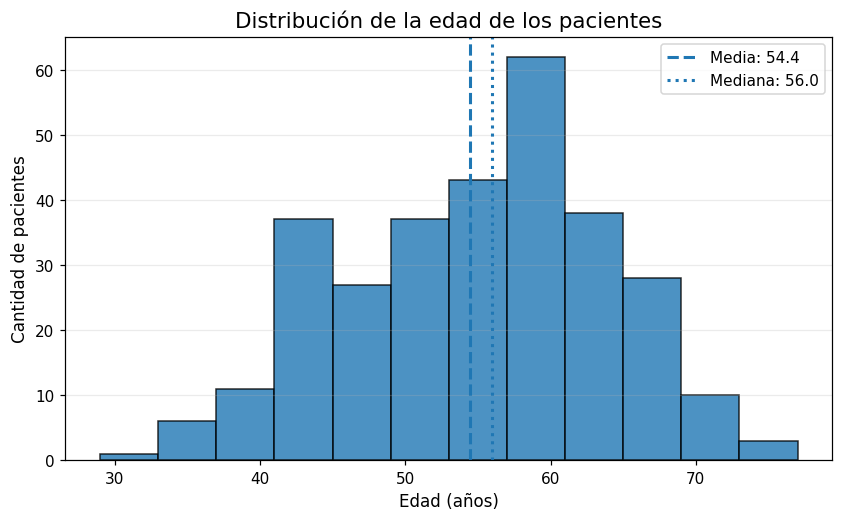

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["edad"].dropna(), bins=12, edgecolor="black", alpha=0.8)
ax.axvline(df["edad"].mean(), linestyle="--", linewidth=2,
           label=f"Media: {df['edad'].mean():.1f}")
ax.axvline(df["edad"].median(), linestyle=":", linewidth=2,
           label=f"Mediana: {df['edad'].median():.1f}")

ax.set_title("Distribución de la edad de los pacientes")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Cantidad de pacientes")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()

**Lectura:** el histograma permite evaluar la concentración, dispersión y posible asimetría de las edades. La comparación entre media y mediana ayuda a detectar si los valores extremos desplazan el promedio.

### Gráfico 2. Presencia de enfermedad según tipo de dolor torácico

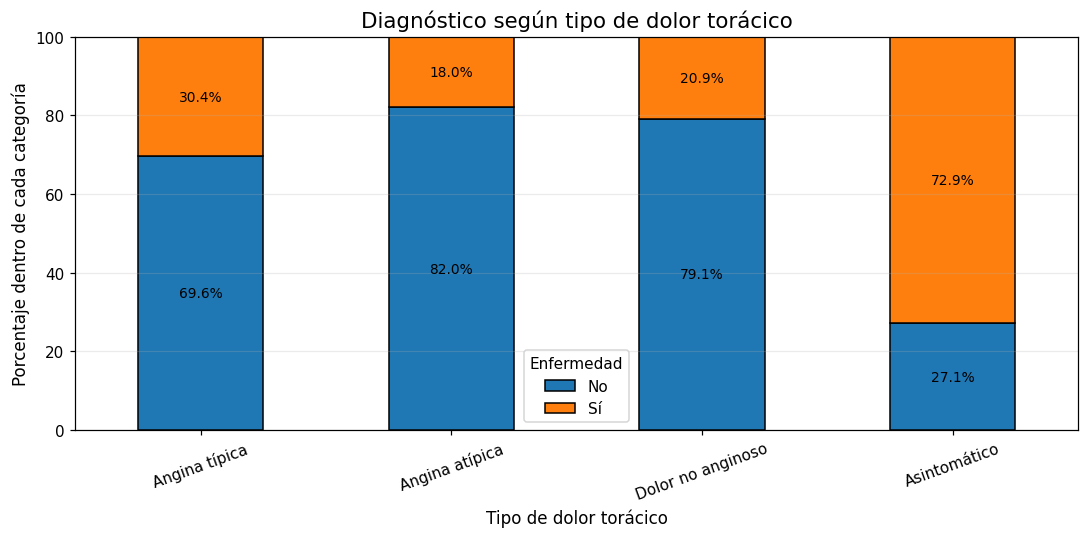

enfermedad,No,Sí
dolor_pecho,,
Angina típica,69.57,30.43
Angina atípica,82.00,18.00
Dolor no anginoso,79.07,20.93
Asintomático,27.08,72.92


In [11]:
tabla_dolor = pd.crosstab(
    df_etiq["dolor_pecho"],
    df_etiq["enfermedad"],
    normalize="index"
).mul(100)

# Se asegura el orden conceptual
orden_dolor = [
    "Angina típica", "Angina atípica",
    "Dolor no anginoso", "Asintomático"
]
tabla_dolor = tabla_dolor.reindex(orden_dolor)

ax = tabla_dolor[["No", "Sí"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    edgecolor="black"
)

ax.set_title("Diagnóstico según tipo de dolor torácico")
ax.set_xlabel("Tipo de dolor torácico")
ax.set_ylabel("Porcentaje dentro de cada categoría")
ax.set_ylim(0, 100)
ax.legend(title="Enfermedad")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.1f%%", label_type="center", fontsize=9)

plt.tight_layout()
plt.show()

tabla_dolor.round(2)

**Lectura:** las barras muestran porcentajes calculados dentro de cada tipo de dolor. Esto evita que una categoría con más pacientes domine la comparación. La asociación observada es descriptiva y no implica causalidad.

### Gráfico 3. Frecuencia cardíaca máxima según diagnóstico

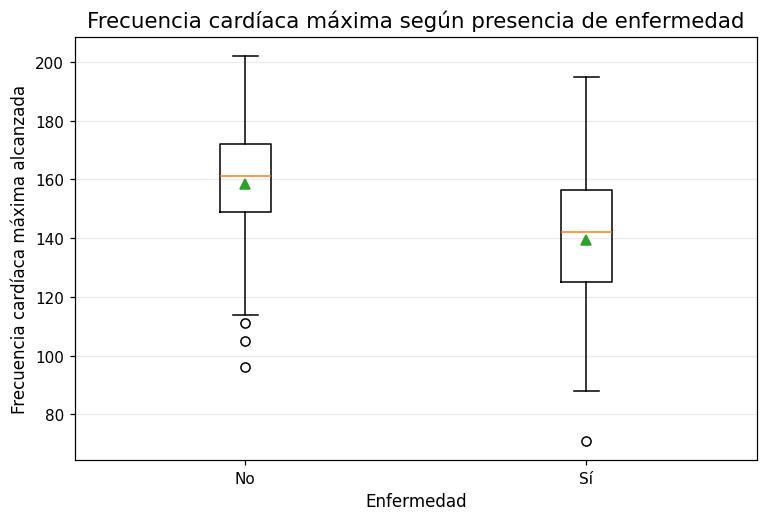

,n,media,mediana,desvio,minimo,maximo
enfermedad,,,,,,
No,164,158.38,161.00,19.20,96.00,202.00
Sí,139,139.26,142.00,22.59,71.00,195.00


In [12]:
datos_box = [
    df.loc[df["enfermedad"] == "No", "fc_maxima"].dropna(),
    df.loc[df["enfermedad"] == "Sí", "fc_maxima"].dropna()
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(datos_box, labels=["No", "Sí"], showmeans=True)

ax.set_title("Frecuencia cardíaca máxima según presencia de enfermedad")
ax.set_xlabel("Enfermedad")
ax.set_ylabel("Frecuencia cardíaca máxima alcanzada")
ax.grid(axis="y", alpha=0.25)
plt.show()

df.groupby("enfermedad")["fc_maxima"].agg(
    n="count", media="mean", mediana="median",
    desvio="std", minimo="min", maximo="max"
).round(2)

**Lectura:** el boxplot permite comparar la mediana, el rango intercuartílico, la dispersión y los posibles valores atípicos entre ambos grupos.

### Gráfico 4. Depresión del segmento ST según diagnóstico

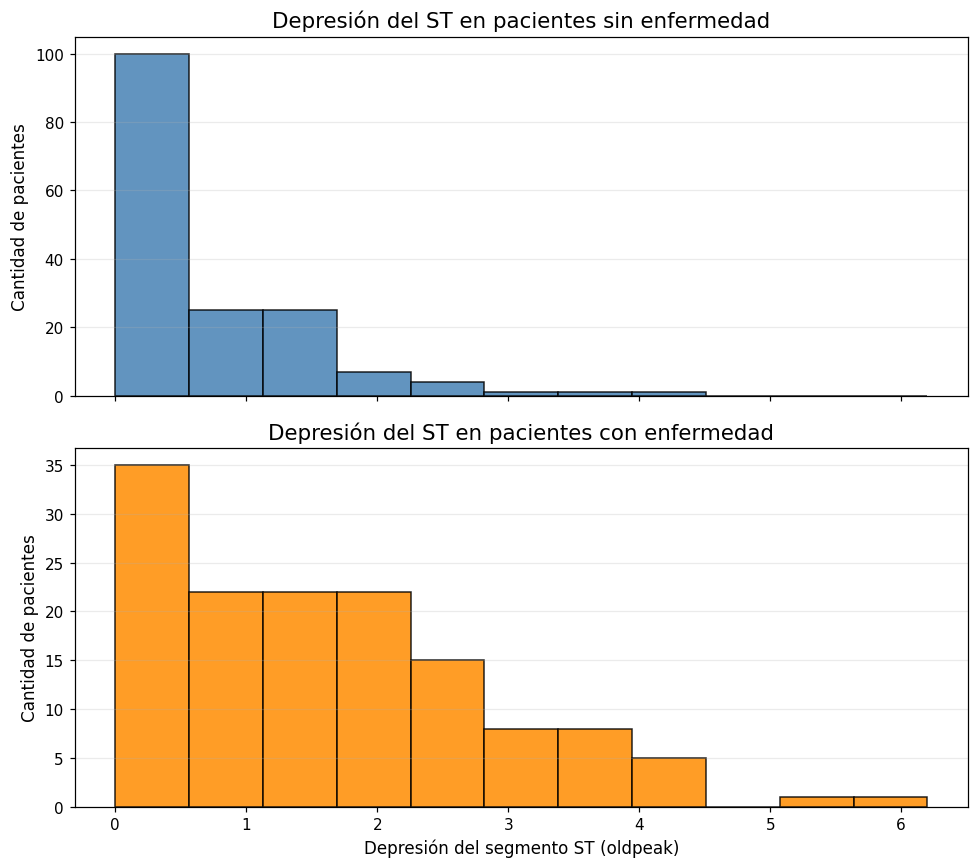

In [18]:
grupo_no = df.loc[df["enfermedad"] == "No", "depresion_st"].dropna()
grupo_si = df.loc[df["enfermedad"] == "Sí", "depresion_st"].dropna()

bins = np.linspace(
    df["depresion_st"].min(),
    df["depresion_st"].max(),
    12
)

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# Sin enfermedad
axes[0].hist(
    grupo_no,
    bins=bins,
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)
axes[0].set_title("Depresión del ST en pacientes sin enfermedad")
axes[0].set_ylabel("Cantidad de pacientes")
axes[0].grid(axis="y", alpha=0.25)

# Con enfermedad
axes[1].hist(
    grupo_si,
    bins=bins,
    color="darkorange",
    edgecolor="black",
    alpha=0.85
)
axes[1].set_title("Depresión del ST en pacientes con enfermedad")
axes[1].set_xlabel("Depresión del segmento ST (oldpeak)")
axes[1].set_ylabel("Cantidad de pacientes")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### ¿Qué representa esta variable?

El **segmento ST** es una parte del trazado del electrocardiograma ubicada entre el final del complejo QRS y el comienzo de la onda T. Representa un momento de la actividad eléctrica de los ventrículos y, en condiciones normales, suele mantenerse cerca de la línea de base del registro.

La **depresión del segmento ST** significa que esa parte del trazado desciende por debajo de la línea de referencia. En este dataset, la variable `depresion_st`, denominada originalmente `oldpeak`, indica cuánto descendió el segmento ST durante el ejercicio en comparación con el electrocardiograma en reposo.

- Un valor cercano a `0` indica poca o ninguna depresión del ST.
- Valores más altos indican un descenso mayor durante el esfuerzo.

Una depresión más marcada puede asociarse con alteraciones de la respuesta cardíaca al ejercicio y con posible isquemia, pero no constituye por sí sola un diagnóstico. Debe interpretarse junto con el resto del electrocardiograma y la información clínica del paciente.


### Gráfico 5. Correlación entre variables cuantitativas

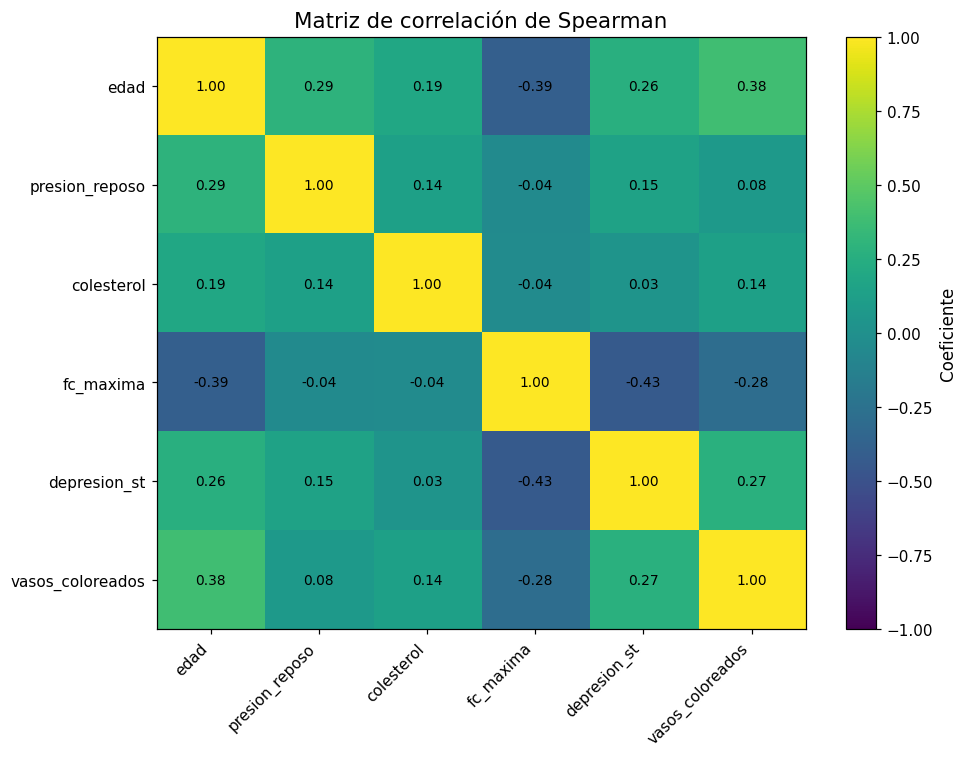

In [14]:
# Correlación de Spearman: adecuada para relaciones monótonas y menos
# dependiente de la normalidad que Pearson.
corr = df[variables_numericas].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
imagen = ax.imshow(corr, vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=9)

ax.set_title("Matriz de correlación de Spearman")
fig.colorbar(imagen, ax=ax, label="Coeficiente")
plt.tight_layout()
plt.show()

### Interpretación responsable de la correlación

- Un coeficiente cercano a `1` indica asociación monótona positiva.
- Un coeficiente cercano a `-1` indica asociación monótona negativa.
- Un valor cercano a `0` indica ausencia de una relación monótona marcada.
- Correlación no equivale a causalidad.
- Las variables codificadas como categorías no se incluyeron en esta matriz, aunque sus códigos sean numéricos.

## 7. Relaciones entre variables: tablas resumen

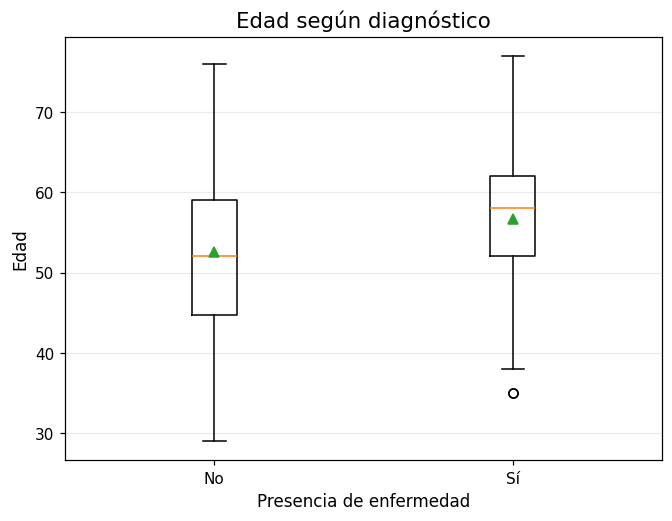

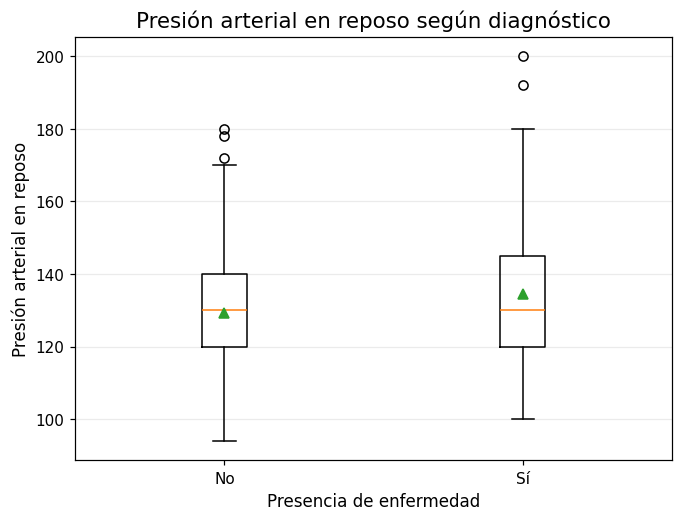

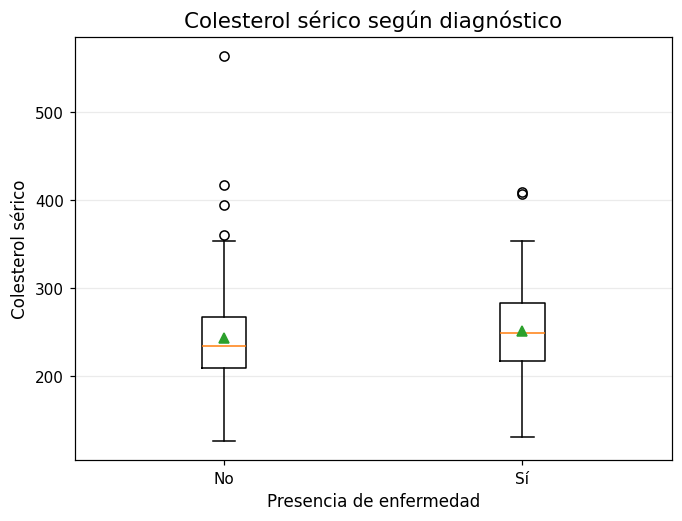

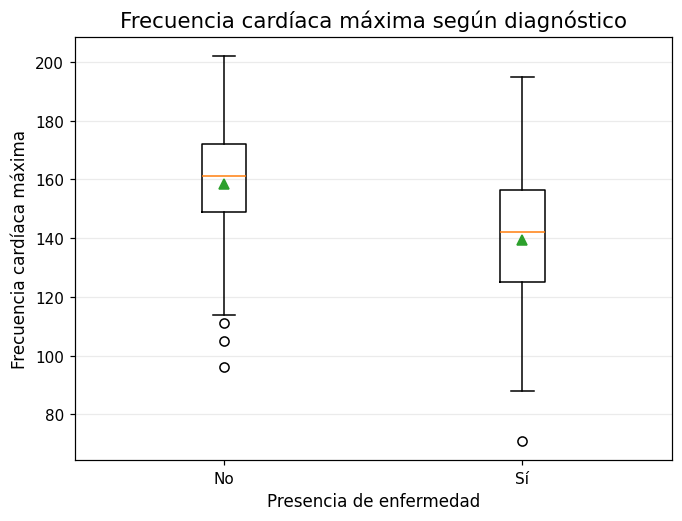

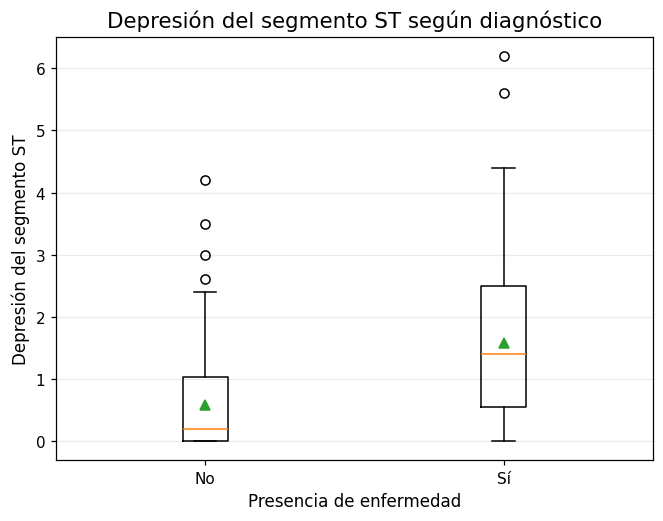

In [23]:
variables = [
    "edad",
    "presion_reposo",
    "colesterol",
    "fc_maxima",
    "depresion_st"
]

titulos = {
    "edad": "Edad",
    "presion_reposo": "Presión arterial en reposo",
    "colesterol": "Colesterol sérico",
    "fc_maxima": "Frecuencia cardíaca máxima",
    "depresion_st": "Depresión del segmento ST"
}

for variable in variables:

    datos_no = df.loc[
        df["enfermedad"] == "No",
        variable
    ].dropna()

    datos_si = df.loc[
        df["enfermedad"] == "Sí",
        variable
    ].dropna()

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.boxplot(
        [datos_no, datos_si],
        labels=["No", "Sí"],
        showmeans=True
    )

    ax.set_title(f"{titulos[variable]} según diagnóstico")
    ax.set_xlabel("Presencia de enfermedad")
    ax.set_ylabel(titulos[variable])
    ax.grid(axis="y", alpha=0.25)

    plt.show()

### Comparación de variables clínicas según diagnóstico

Los gráficos comparan la distribución de distintas variables clínicas entre los pacientes sin enfermedad y con enfermedad.

En la muestra analizada, el grupo con enfermedad presenta una edad promedio mayor, una frecuencia cardíaca máxima menor y valores más altos de depresión del segmento ST. Las diferencias en presión arterial y colesterol son menos marcadas.

Los boxplots permiten observar la mediana, la dispersión y los posibles valores atípicos de cada variable. Estas diferencias son descriptivas y no implican que una variable, por sí sola, determine la presencia de enfermedad.

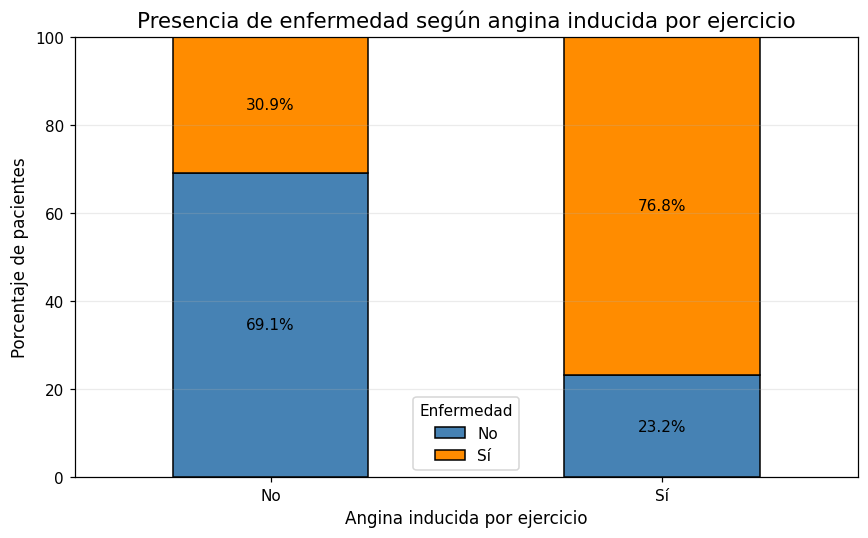

In [24]:
ax = relacion_angina[["No", "Sí"]].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["steelblue", "darkorange"],
    edgecolor="black"
)

ax.set_title("Presencia de enfermedad según angina inducida por ejercicio")
ax.set_xlabel("Angina inducida por ejercicio")
ax.set_ylabel("Porcentaje de pacientes")
ax.set_ylim(0, 100)
ax.legend(title="Enfermedad")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt="%.1f%%",
        label_type="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Relación entre angina inducida por ejercicio y enfermedad

La angina inducida por ejercicio es un dolor o molestia en el pecho que aparece durante el esfuerzo físico, cuando el corazón necesita recibir más oxígeno.

En la muestra analizada, el 76,8 % de los pacientes que presentaron angina durante el ejercicio también registraron enfermedad cardíaca. En cambio, entre quienes no tuvieron angina inducida por ejercicio, la proporción de enfermedad fue del 30,9 %.

Esto muestra una asociación marcada entre ambas variables dentro de la muestra. Sin embargo, no significa que la angina inducida por ejercicio sea suficiente por sí sola para diagnosticar enfermedad cardíaca.

## 8. Generación automática de hallazgos verificables

In [25]:
n = len(df)
casos_si = (df["enfermedad"] == "Sí").sum()
pct_si = casos_si / n * 100

edad_media = df["edad"].mean()
edad_mediana = df["edad"].median()

fc_grupos = df.groupby("enfermedad")["fc_maxima"].median()
st_grupos = df.groupby("enfermedad")["depresion_st"].median()

categoria_mayor = tabla_dolor["Sí"].idxmax()
porcentaje_mayor = tabla_dolor.loc[categoria_mayor, "Sí"]

print("HALLAZGOS DESCRIPTIVOS")
print(f"1. La base contiene {n} pacientes.")
print(f"2. {casos_si} registros ({pct_si:.1f}%) presentan diagnóstico codificado entre 1 y 4.")
print(f"3. La edad media es {edad_media:.1f} años y la mediana es {edad_mediana:.1f} años.")
print(
    f"4. La mediana de frecuencia cardíaca máxima es "
    f"{fc_grupos['No']:.1f} en el grupo sin enfermedad y "
    f"{fc_grupos['Sí']:.1f} en el grupo con enfermedad."
)
print(
    f"5. La mediana de depresión del ST es "
    f"{st_grupos['No']:.1f} en el grupo sin enfermedad y "
    f"{st_grupos['Sí']:.1f} en el grupo con enfermedad."
)
print(
    f"6. La categoría de dolor torácico con mayor proporción observada "
    f"de enfermedad es '{categoria_mayor}', con {porcentaje_mayor:.1f}%."
)

HALLAZGOS DESCRIPTIVOS
1. La base contiene 303 pacientes.
2. 139 registros (45.9%) presentan diagnóstico codificado entre 1 y 4.
3. La edad media es 54.4 años y la mediana es 56.0 años.
4. La mediana de frecuencia cardíaca máxima es 161.0 en el grupo sin enfermedad y 142.0 en el grupo con enfermedad.
5. La mediana de depresión del ST es 0.2 en el grupo sin enfermedad y 1.4 en el grupo con enfermedad.
6. La categoría de dolor torácico con mayor proporción observada de enfermedad es 'Asintomático', con 72.9%.


## 9. Conclusiones

El análisis permite describir la composición de la base de Cleveland y examinar asociaciones entre variables clínicas y el diagnóstico registrado. Las visualizaciones comparan la distribución de la edad, el tipo de dolor torácico, la frecuencia cardíaca máxima y la depresión del segmento ST.

Las diferencias observadas entre grupos son asociaciones dentro de esta muestra. No permiten afirmar que una variable cause la enfermedad, ni que por sí sola tenga capacidad diagnóstica. También debe considerarse que la base es histórica, contiene una muestra clínica específica y presenta una distribución por sexo y diagnóstico que puede no representar a la población general.

Para un trabajo posterior podrían evaluarse pruebas estadísticas, modelos predictivos con validación y métricas adecuadas; sin embargo, esas etapas exceden el alcance de este EDA básico.

## 10. Fuente y reconocimiento

Los datos fueron obtenidos del conjunto **Heart Disease**, disponible en el **UCI Machine Learning Repository**.

**Enlace:** [https://archive.ics.uci.edu/dataset/45/heart+disease](https://archive.ics.uci.edu/dataset/45/heart+disease).

La documentación original solicita reconocer a los investigadores responsables de la recolección. Para Cleveland Clinic Foundation y V.A. Medical Center, Long Beach, se menciona a **Robert Detrano, M.D., Ph.D.**

Este análisis utiliza las 14 variables seleccionadas que fueron empleadas históricamente en experimentos con la base.